# Time Series Forecasting with TerraТorch: Air Quality Tutorial

This tutorial introduces the **time-series capabilities** added in the latest TerraТorch release. We walk through a complete forecasting workflow, from raw data to trained model to visual results, using three new components:

| Component | Description |
|-----------|-------------|
| `AirQuality` / `AirQualityDataModule` | Hourly air-quality sensor data (UCI, Italian roadside station, 2004–2005) with chronological splitting and per-feature normalisation |
| `LTAE` | Lightweight Temporal Attention Encoder — encodes a variable-length sequence `(B, T, C)` into a fixed embedding `(B, d)` |
| `TemporalRegressionTask` | Lightning module that wires the encoder to a regression head, loss function, and evaluation metrics |

**What we are predicting:** given the last `NUM_PAST_STEPS` hours across all sensor channels, forecast the next `NUM_FUTURE_STEPS` hours for all channels simultaneously.

## 1. Setup

We import everything we need upfront. `L.seed_everything` ensures reproducible weight initialisation and data shuffling across runs.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import lightning as L
from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from torchgeo.datasets import AirQuality
from torchgeo.datamodules import AirQualityDataModule
from torchgeo.models import LTAE
from torchgeo.trainers import TemporalRegressionTask

warnings.filterwarnings('ignore')
L.seed_everything(0, workers=True)

print(f'torch     : {torch.__version__}')
print(f'lightning : {L.__version__}')
print(f'CUDA      : {torch.cuda.is_available()}')

# Temporary workaround: disable inplace dropout in LTAE
_original_init = LTAE.__init__
def patched_init(self, *args, **kwargs):
    _original_init(self, *args, **kwargs)
    for m in self.modules():
        if isinstance(m, nn.Dropout):
            m.inplace = False
LTAE.__init__ = patched_init

/home/fschi/miniconda3/envs/torchgeo-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 0


torch     : 2.5.1
lightning : 2.5.2
CUDA      : False


## 2. Dataset

The **UCI Air Quality dataset** contains 13 sensor channels (we remove NMHC(GT) for this analysis, which contains mostly empty readings) measured every hour for approximately 13 months at a roadside station in Italy. Missing values (encoded as `-200` in the raw data) are handled automatically by `AirQuality`.

Each sample in the dataset consists of:
- **`x_input`**: a window of `NUM_PAST_STEPS` hourly readings across all channels (shape `T × C`)
- **`y_target`**: the following `NUM_FUTURE_STEPS` hourly readings (shape `H × C`)

We set a 72-hour context window (3 days) and ask the model to predict 12 hours ahead.

In [2]:
DATA_ROOT        = 'data'
NUM_PAST_STEPS   = 72   # hours of context fed to the model
NUM_FUTURE_STEPS = 12   # hours ahead to predict

dataset = AirQuality(
    root=DATA_ROOT,
    download=True,
    num_input_steps=NUM_PAST_STEPS,
    num_target_steps=NUM_FUTURE_STEPS,
)

FEATURE_NAMES = dataset.data.columns.tolist()
NUM_FEATURES  = len(FEATURE_NAMES)

print(f'Total samples : {len(dataset):,}')
print(f'Channels (C)  : {NUM_FEATURES}')
print(f'  -> {FEATURE_NAMES}')
print(f'Input  shape  : ({NUM_PAST_STEPS}, {NUM_FEATURES})  — (T, C)')
print(f'Target shape  : ({NUM_FUTURE_STEPS}, {NUM_FEATURES})  — (H, C)')

dataset.data.head()

Total samples : 9,273
Channels (C)  : 12
  -> ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Input  shape  : (72, 12)  — (T, C)
Target shape  : (12, 12)  — (H, C)


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


### 2.1 Raw signal overview

Let's take a look at all 12 channels over a two-week window used for this analysis. The strong diurnal rhythm visible in most channels driven by rush-hour traffic patterns is the overarching temporal structure the model needs to learn.

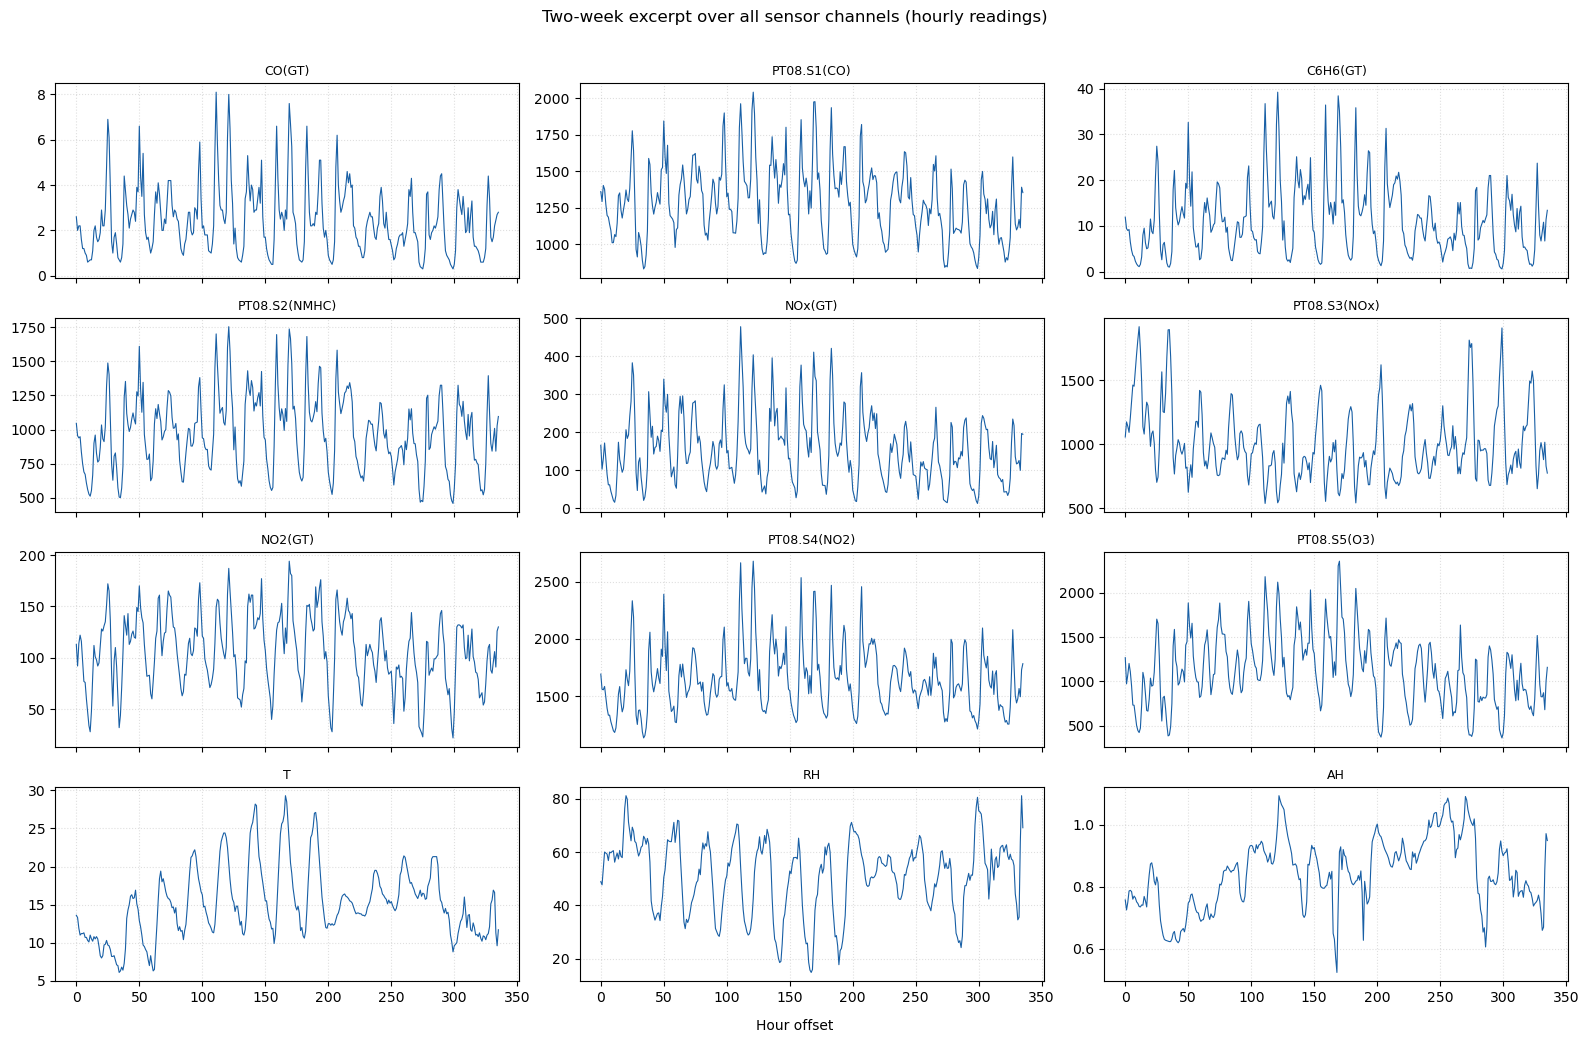

In [16]:
df     = dataset.data
window = slice(0, 24 * 14)   # first two weeks
n_cols = 3
n_rows = int(np.ceil(NUM_FEATURES / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.5), sharex=True)
axes_flat = axes.flatten()

for i, name in enumerate(FEATURE_NAMES):
    axes_flat[i].plot(df[name].iloc[window].values, linewidth=0.8, color='#185FA5')
    axes_flat[i].set_title(name, fontsize=9)
    axes_flat[i].grid(True, linestyle=':', alpha=0.4)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Two-week excerpt over all sensor channels (hourly readings)', fontsize=12, y=1.01)
fig.text(0.5, -0.01, 'Hour offset', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 2.2 A single sample

Each dataset item provides the input context (solid lines) and the prediction target (dashed lines) for all channels. The built-in `plot` method visualises this directly.

x_input  shape : torch.Size([72, 12])  (T, C)
y_target shape : torch.Size([12, 12])  (H, C)


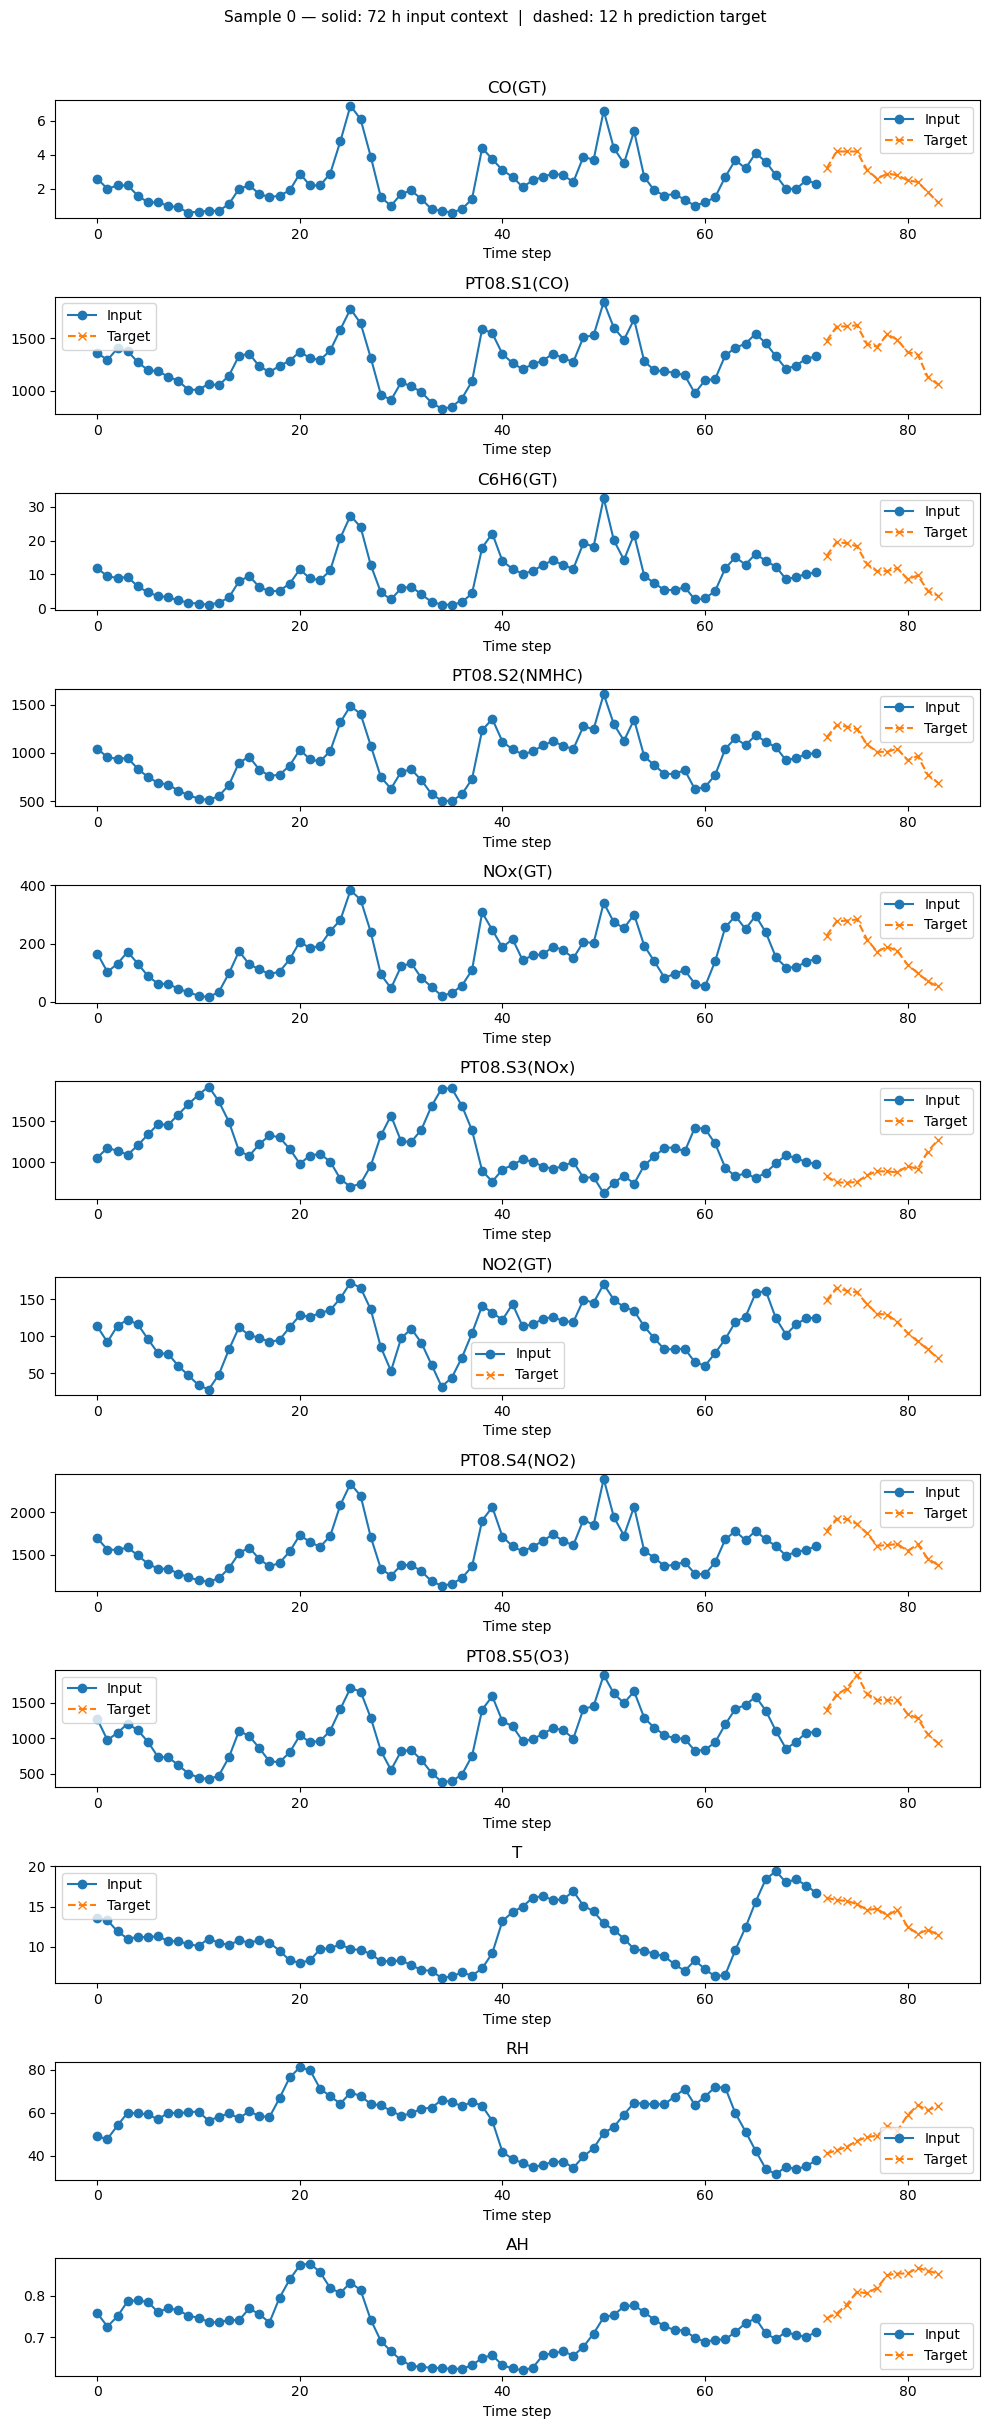

In [4]:
sample = dataset[0]
print(f"x_input  shape : {sample['x_input'].shape}  (T, C)")
print(f"y_target shape : {sample['y_target'].shape}  (H, C)")

fig = dataset.plot(sample)
fig.suptitle(
    f'Sample 0 — solid: {NUM_PAST_STEPS} h input context  |  dashed: {NUM_FUTURE_STEPS} h prediction target',
    y=1.01, fontsize=11
)
plt.tight_layout()
plt.show()

## 3. The L-TAE Model

The **Lightweight Temporal Attention Encoder** (Garnot & Landrieu, 2020) is designed for variable-length time series. Instead of processing steps sequentially like an RNN, it computes a single learned query vector that attends to *all* timesteps at once, yielding a fixed-size embedding regardless of sequence length.

The forward pass looks like this:

```
Input  (B, T, C)
  → Linear projection      (B, T, d_model)
  → Multi-head temporal attention   ← one learned query per head
  → Attention-weighted sum (B, d_model)
  → MLP                    (B, n_neurons[-1])
```

This architecture is well-suited for irregular or long time series: it avoids the vanishing-gradient issues of RNNs and assigns an explicit, inspectable attention weight to every timestep.

In [5]:
# Encoder hyperparameters
D_MODEL   = 64
N_NEURONS = (64, 32)   # MLP dimensions after attention pooling; first must equal D_MODEL
N_HEAD    = 4
D_K       = 8
DROPOUT   = 0.1

ltae = LTAE(
    in_channels = NUM_FEATURES,
    n_head      = N_HEAD,
    d_k         = D_K,
    d_model     = D_MODEL,
    n_neurons   = N_NEURONS,
    dropout     = DROPOUT,
    len_max_seq = NUM_PAST_STEPS,
    T           = 1000,
)

dummy_x   = torch.randn(4, NUM_PAST_STEPS, NUM_FEATURES)
dummy_out = ltae(dummy_x)

print(f'Input  shape : {tuple(dummy_x.shape)}   (B, T, C)')
print(f'Output shape : {tuple(dummy_out.shape)}  (B, embedding_dim)')
print(f'Trainable parameters : {sum(p.numel() for p in ltae.parameters() if p.requires_grad):,}')

Input  shape : (4, 72, 12)   (B, T, C)
Output shape : (4, 32)  (B, embedding_dim)
Trainable parameters : 28,920


## 4. The TemporalRegressionTask

`TemporalRegressionTask` is a Lightning module that wraps the L-TAE encoder together with a linear prediction head. It handles the full training loop including:
- **Loss**: MSE computed in normalised space
- **Metrics**: RMSE and MAE reported in physical units (de-normalised before metric computation)
- **Learning rate scheduling**: via the `patience` parameter

The output dimension `NUM_OUTPUTS = NUM_FUTURE_STEPS × NUM_FEATURES` reflects that we predict all channels at every future timestep simultaneously.

In [6]:
# Task hyperparameters
NUM_OUTPUTS = NUM_FUTURE_STEPS * NUM_FEATURES
LOSS        = 'mse'
LR          = 3e-4
PATIENCE    = 5

print(f'Input tensor  : ({NUM_PAST_STEPS}, {NUM_FEATURES})   T steps x C channels')
print(f'Output tensor : {NUM_OUTPUTS}   = {NUM_FUTURE_STEPS} future steps x {NUM_FEATURES} channels')


def make_task():
    """Factory so we can re-instantiate the task cleanly after exploring."""
    return TemporalRegressionTask(
        model       = 'ltae',
        in_channels = NUM_FEATURES,
        num_outputs = NUM_OUTPUTS,
        loss        = LOSS,
        lr          = LR,
        patience    = PATIENCE,
        n_head      = N_HEAD,
        d_k         = D_K,
        d_model     = D_MODEL,
        n_neurons   = N_NEURONS,
        dropout     = DROPOUT,
        len_max_seq = NUM_PAST_STEPS,
        T           = 1000,
    )


task = make_task()
print(f'\nTrainable parameters : {sum(p.numel() for p in task.parameters() if p.requires_grad):,}')

# Quick sanity check on synthetic data
dummy_batch = {
    'x_input'  : torch.randn(4, NUM_PAST_STEPS, NUM_FEATURES),
    'y_target' : torch.randn(4, NUM_FUTURE_STEPS, NUM_FEATURES),
    'mean'     : torch.zeros(NUM_FEATURES),
    'std'      : torch.ones(NUM_FEATURES),
}
task.eval()
with torch.no_grad():
    pred = task.predict_step(dummy_batch, batch_idx=0)
assert pred.shape == (4, NUM_OUTPUTS)
task.train()
loss_val = task.training_step(dummy_batch, batch_idx=0)
assert loss_val.isfinite()
print('Sanity checks passed — task is ready.')

Input tensor  : (72, 12)   T steps x C channels
Output tensor : 144   = 12 future steps x 12 channels

Trainable parameters : 33,672
Sanity checks passed — task is ready.


## 5. Data Module and Chronological Splitting

`AirQualityDataModule` handles loading, normalisation, and splitting in one place. The split is always **chronological** — training on the earliest data, validating on the middle, and testing on the most recent, because random splits would cause temporal leakage: the model would have seen future information during training.

Per-feature z-score normalisation is computed from the training set only and applied consistently to all splits.

In [7]:
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
BATCH_SIZE = 128

dm = AirQualityDataModule(
    root             = DATA_ROOT,
    download         = True,
    batch_size       = BATCH_SIZE,
    num_workers      = 0,
    val_split_pct    = VAL_SPLIT,
    test_split_pct   = TEST_SPLIT,
    num_input_steps  = NUM_PAST_STEPS,
    num_target_steps = NUM_FUTURE_STEPS,
)
dm.setup(stage='fit')

n_train = len(dm.train_dataset)
n_val   = len(dm.val_dataset)
n_test  = len(dm.test_dataset)
n_total = n_train + n_val + n_test

print(f'{"Split":<14} {"Samples":>8}   {"Share":>6}')
print(f'{"Train":<14} {n_train:>8,}   {n_train/n_total:>5.0%}')
print(f'{"Validation":<14} {n_val:>8,}   {n_val/n_total:>5.0%}')
print(f'{"Test":<14} {n_test:>8,}   {n_test/n_total:>5.0%}')

# Verify normalisation is active
batch = next(iter(dm.train_dataloader()))
batch = dm.on_after_batch_transfer(batch, dataloader_idx=0)
print(f'\nNormalisation check (should be ~0 and ~1):')
print(f'  x_input mean : {batch["x_input"].mean().item():.4f}')
print(f'  x_input std  : {batch["x_input"].std().item():.4f}')

Split           Samples    Share
Train             6,491     71%
Validation        1,390     15%
Test              1,224     13%

Normalisation check (should be ~0 and ~1):
  x_input mean : -0.0132
  x_input std  : 0.9755


## 6. Training

We use two standard Lightning callbacks:
- **`ModelCheckpoint`**: saves the weights that achieved the lowest validation loss
- **`EarlyStopping`**: halts training if validation loss does not improve for `EARLY_STOP_PATIENCE` consecutive epochs

All metrics are logged to a CSV file by `CSVLogger`, which we will read back for plotting.

In [8]:
MAX_EPOCHS          = 30
EARLY_STOP_PATIENCE = 10

task = make_task()

checkpoint_cb = ModelCheckpoint(
    monitor='val_loss', mode='min', save_top_k=1,
    filename='best-{epoch:02d}-{val_loss:.4f}',
)
early_stop_cb = EarlyStopping(
    monitor='val_loss', patience=EARLY_STOP_PATIENCE, mode='min',
)

trainer = Trainer(
    logger            = CSVLogger(save_dir='lightning_logs', name='airquality'),
    max_epochs        = MAX_EPOCHS,
    callbacks         = [checkpoint_cb, early_stop_cb],
    log_every_n_steps = 10,
)

trainer.fit(task, datamodule=dm)

print(f'\nBest checkpoint : {checkpoint_cb.best_model_path}')
print(f'Best val loss   : {checkpoint_cb.best_model_score:.6f}')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | encoder       | LTAE             | 28.9 K | train
1 | head          | Linear           | 4.8 K  | train
2 | model         | Sequential       | 33.7 K | train
3 | criterion     | MSELoss          | 0      | train
4 | train_metrics | MetricCollection | 0      | train
5 | val_metrics   | MetricCollection | 0      | train
6 | test_metrics  | MetricCollection | 0      | train
-----------------------------------------------------------
33.7 K    Trainable params
0         Non-trainable params
33.7 K    Total params
0.135     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Epoch 28: 100%|██████████| 50/50 [00:02<00:00, 16.90it/s, v_num=10]        

Best checkpoint : lightning_logs/airquality/version_10/checkpoints/best-epoch=18-val_loss=0.7818.ckpt
Best val loss   : 0.781847


## 7. Training Curves

The left panel shows MSE in normalised space (the actual optimisation objective). The right panel shows RMSE and MAE in the original physical units, averaged across all channels. A consistent gap between train and validation loss would indicate overfitting; early stopping helps keep the model in the right regime.

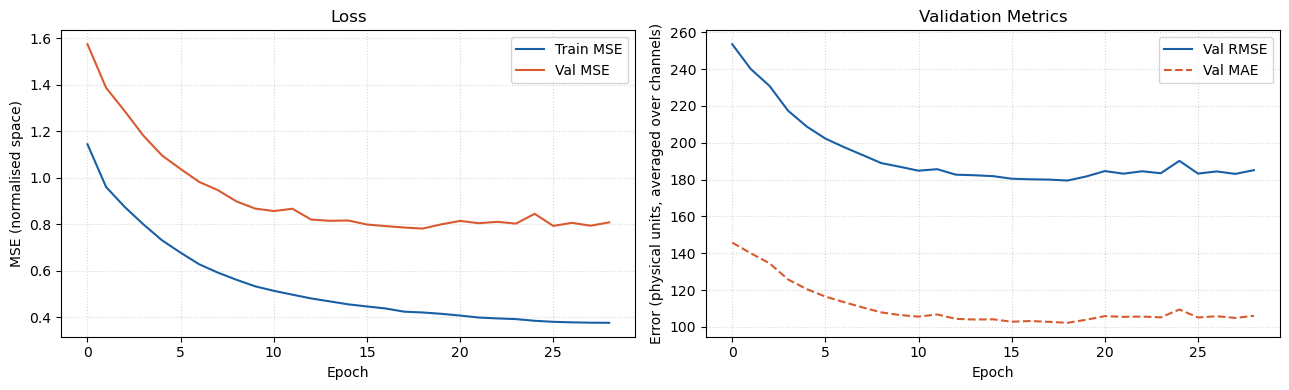

In [9]:
metrics_path = os.path.join(trainer.logger.log_dir, 'metrics.csv')
metrics_df   = pd.read_csv(metrics_path)

train_df = metrics_df[metrics_df['train_loss'].notna()][['epoch', 'train_loss']].dropna()
val_df   = metrics_df[metrics_df['val_loss'].notna()][['epoch', 'val_loss', 'val_RMSE', 'val_MAE']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_df['epoch'], train_df['train_loss'], label='Train MSE', color='#185FA5')
axes[0].plot(val_df['epoch'],   val_df['val_loss'],     label='Val MSE',   color='#D85A30')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (normalised space)')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(val_df['epoch'], val_df['val_RMSE'], label='Val RMSE', color='#185FA5')
axes[1].plot(val_df['epoch'], val_df['val_MAE'],  label='Val MAE',  color='#D85A30', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Error (physical units, averaged over channels)')
axes[1].set_title('Validation Metrics'); axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Test-Set Evaluation

We reload the best checkpoint and run `trainer.test` on the held-out test split. The reported RMSE and MAE are in physical units, averaged across all 12 channels.

In [10]:
best_task = TemporalRegressionTask.load_from_checkpoint(checkpoint_cb.best_model_path)
dm.setup(stage='test')
test_results = trainer.test(best_task, datamodule=dm, verbose=True)

Testing DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 19.72it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_MAE          │     98.4118423461914      │
│         test_MSE          │        29120.34375        │
│         test_RMSE         │    170.64683532714844     │
│         test_loss         │    0.7340860962867737     │
└───────────────────────────┴───────────────────────────┘

## 9. Visualising Predictions

To go beyond aggregate metrics, we collect the model's predictions on the test set and inspect them visually. For each of the 12 channels we plot:
- **Input context**: the 72 hours of observations fed to the model
- **Ground truth**: what actually happened in the next 12 hours
- **L-TAE prediction**: what the model forecasted

The vertical dashed line marks the forecast origin (the boundary between past and future).

In [11]:
# Collect predictions and targets over the full test set
dm.predict_dataset = dm.test_dataset
predictions = trainer.predict(best_task, datamodule=dm)
all_preds   = torch.cat(predictions, dim=0)   # (N_test, NUM_OUTPUTS)

all_targets_list, all_past_list = [], []
for batch in dm.test_dataloader():
    all_targets_list.append(batch['y_target'])
    all_past_list.append(batch['x_input'])

all_targets = torch.cat(all_targets_list, dim=0)   # (N, H, C)
all_past    = torch.cat(all_past_list,    dim=0)   # (N, T, C)

print(f'Test samples : {all_targets.shape[0]:,}')
print(f'Predictions  : {all_preds.shape}   (N, NUM_FUTURE_STEPS x NUM_FEATURES)')

Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 11.42it/s]
Test samples : 1,224
Predictions  : torch.Size([1224, 144])   (N, NUM_FUTURE_STEPS x NUM_FEATURES)


### 9.1 Per-channel forecast plots

We plot a single representative test sample for every channel. This gives an intuitive picture of where the model is accurate and where it struggles.

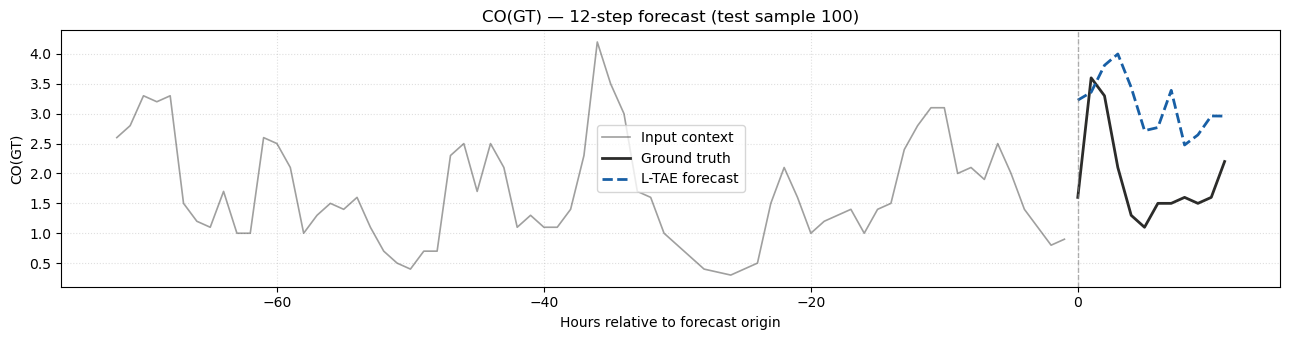

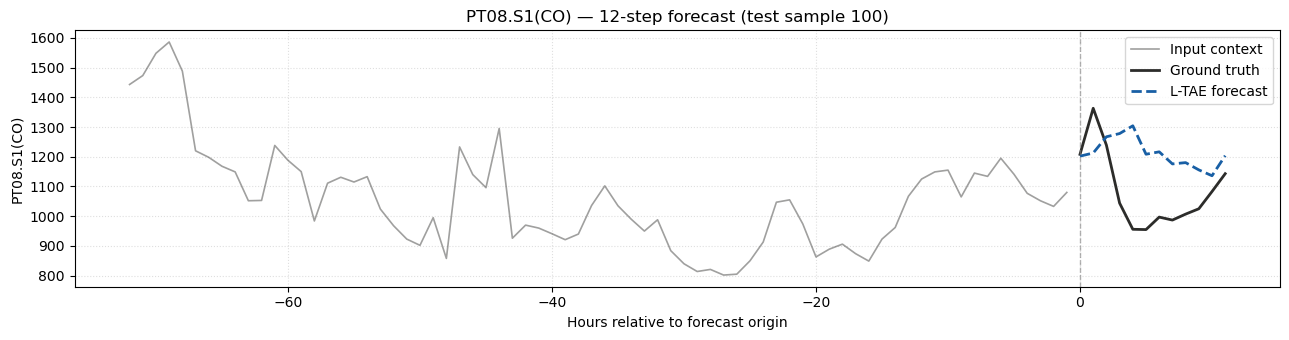

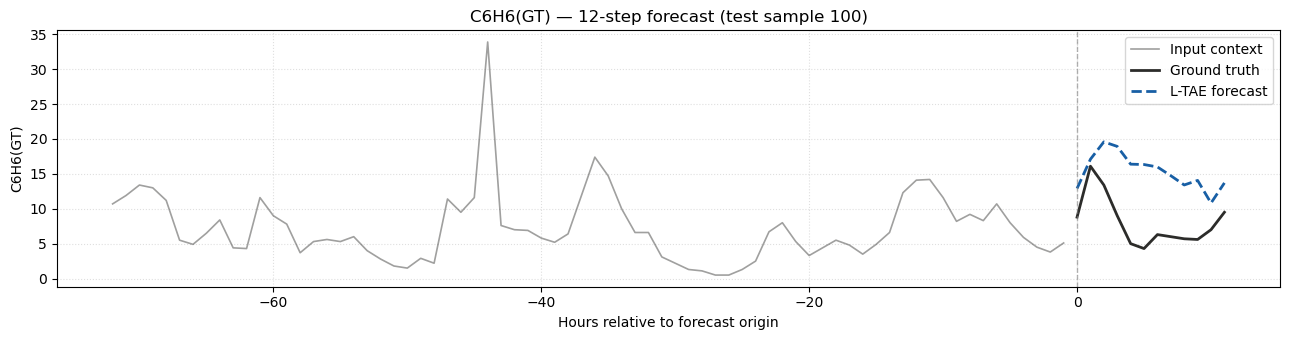

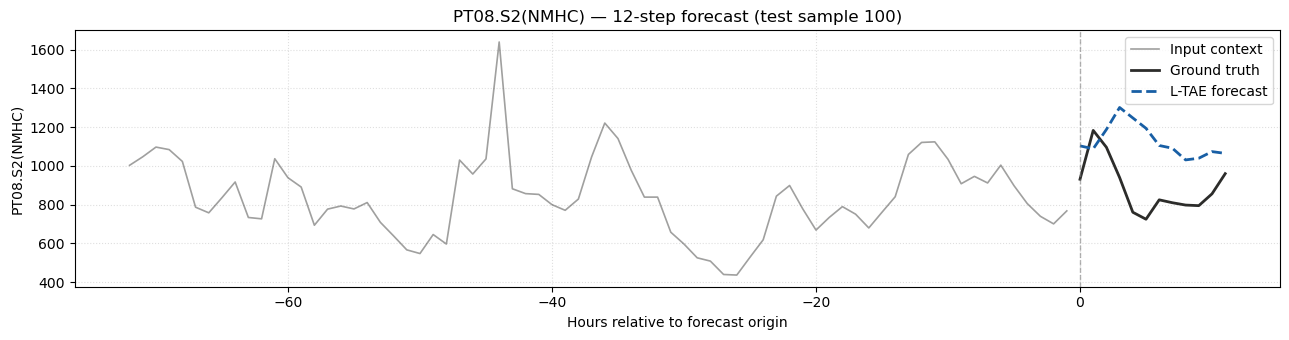

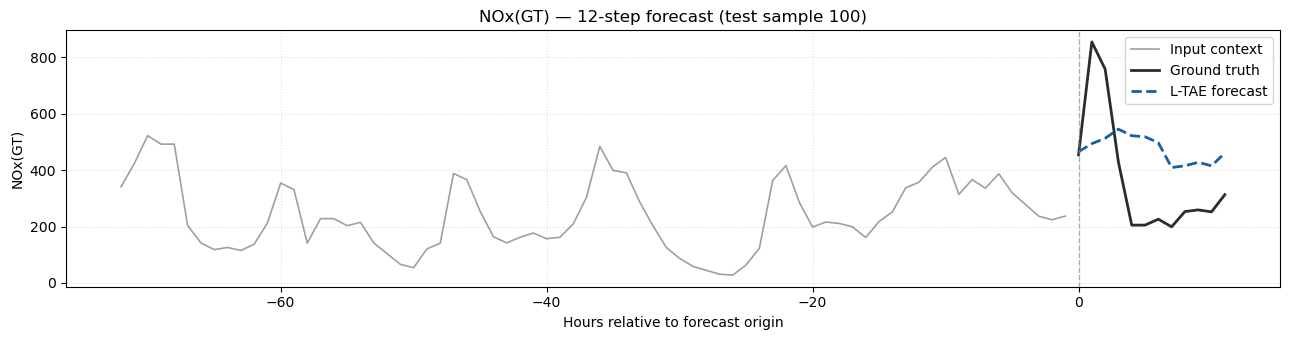

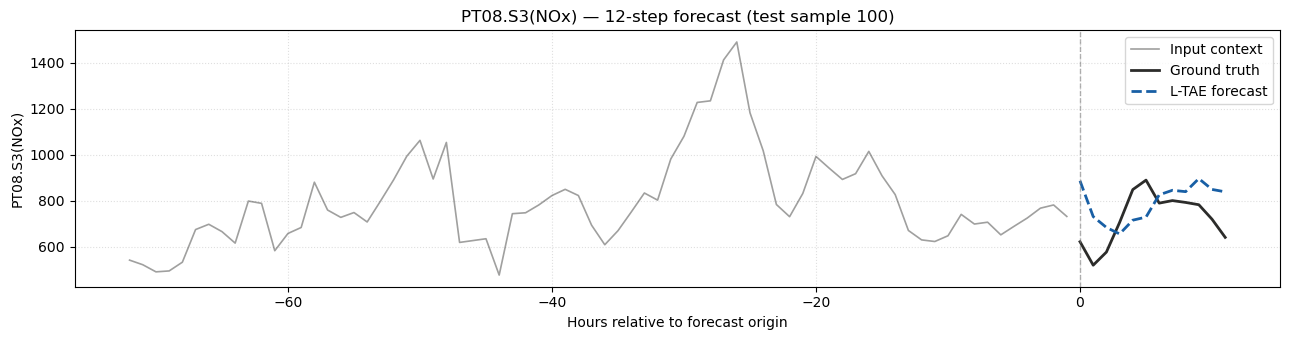

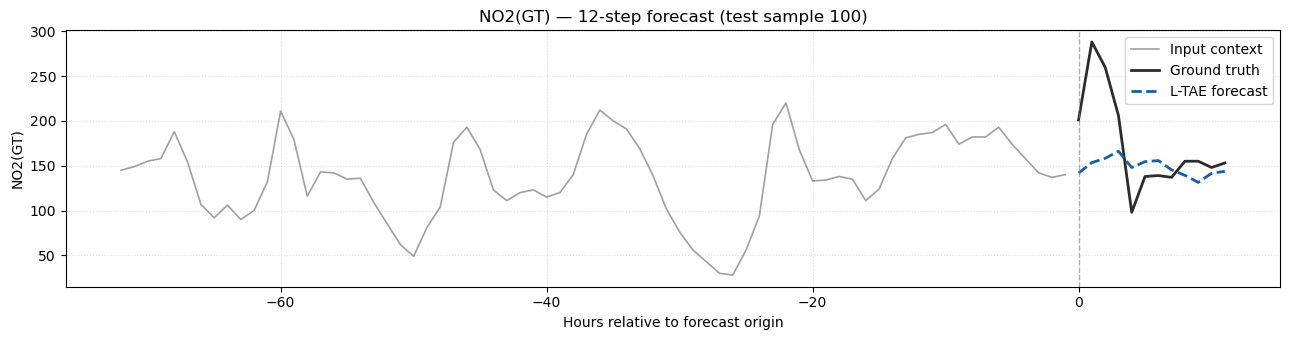

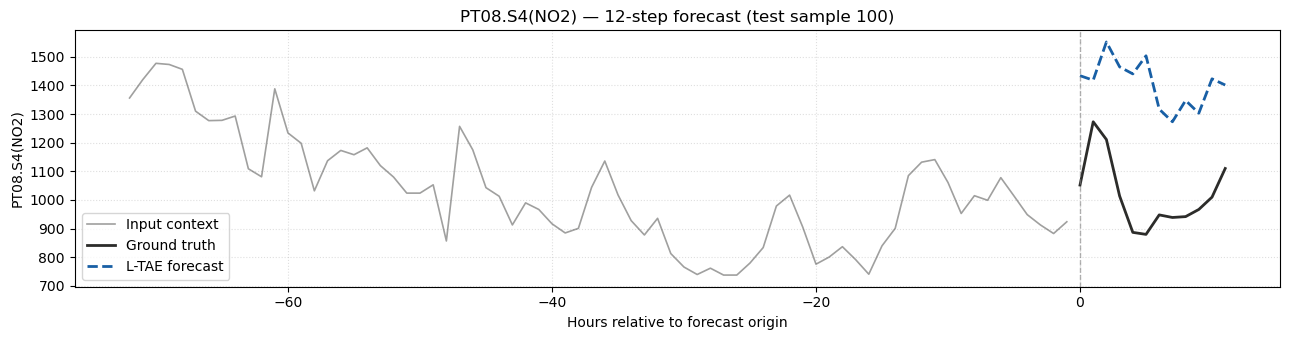

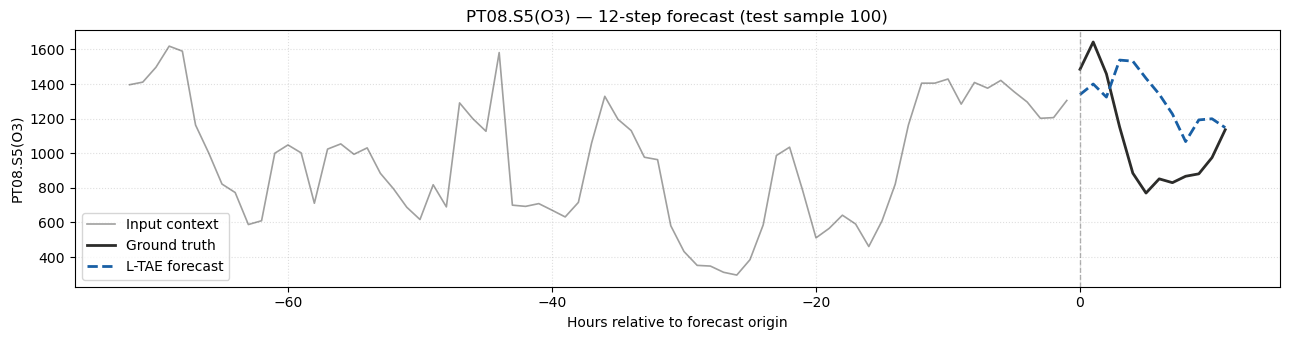

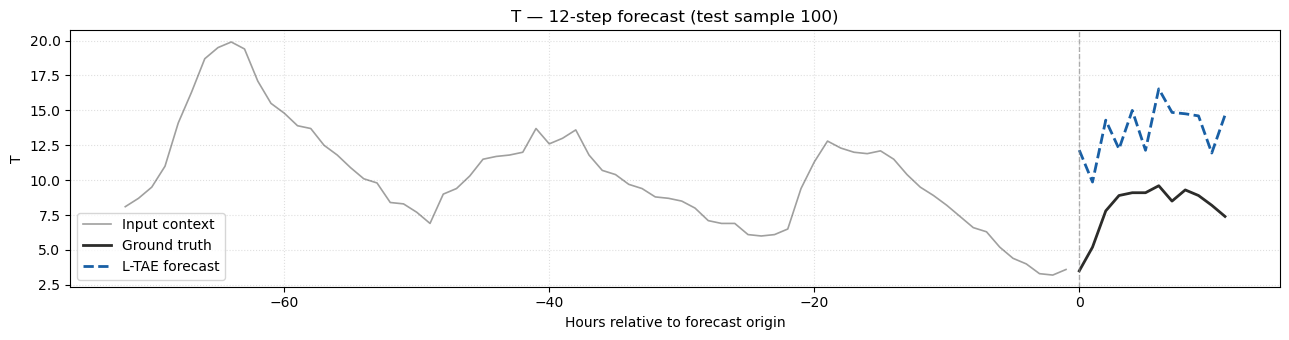

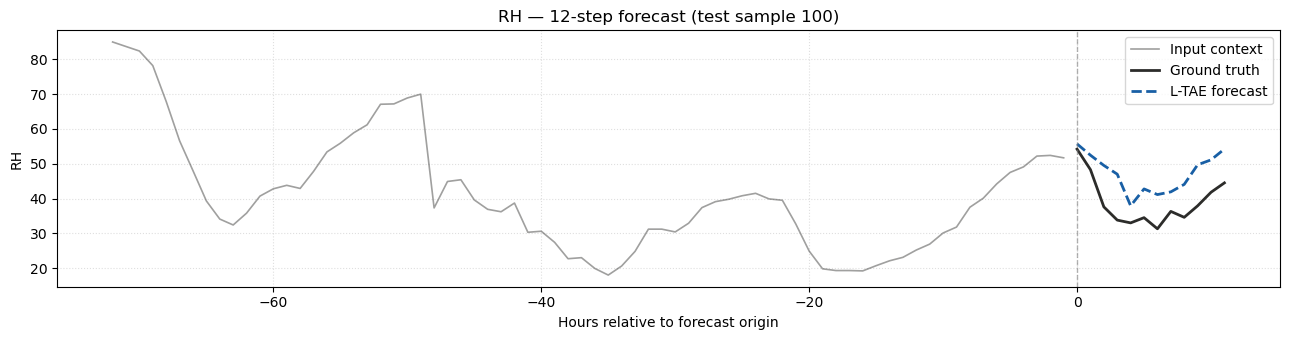

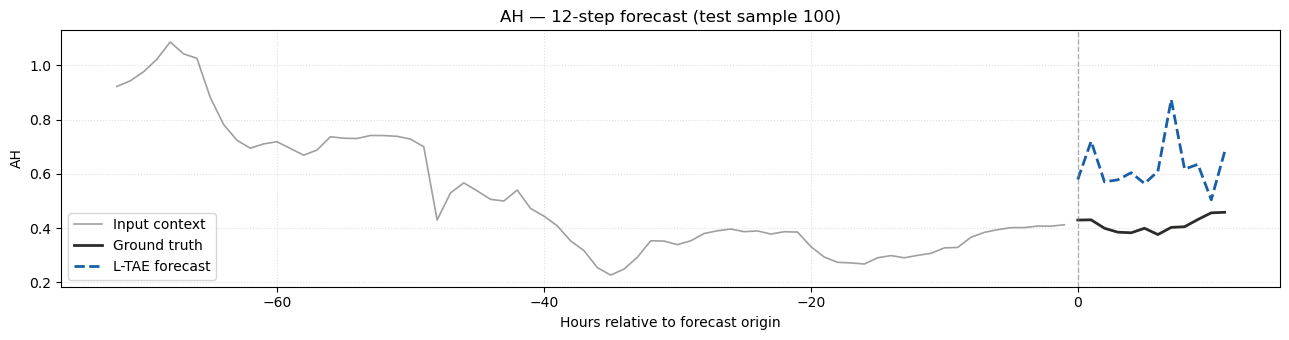

In [12]:
H         = NUM_FUTURE_STEPS
T         = NUM_PAST_STEPS
SAMPLE_ID = 100   # change this to inspect a different test sample

t_past   = np.arange(-T, 0)   # -T .. -1
t_fut    = np.arange(0, H)    #  0 .. H-1

pred_3d = all_preds.view(-1, H, NUM_FEATURES).detach().numpy()  # (N, H, C)

for idx, name in enumerate(FEATURE_NAMES):
    past_vals = all_past[SAMPLE_ID, :, idx].detach().numpy()
    gt_vals   = all_targets[SAMPLE_ID, :, idx].detach().numpy()
    pred_vals = pred_3d[SAMPLE_ID, :, idx]

    fig, ax = plt.subplots(figsize=(13, 3.5))

    ax.plot(t_past, past_vals, label='Input context',
            color='#2C2C2A', linewidth=1.2, alpha=0.45)
    ax.plot(t_fut,  gt_vals,   label='Ground truth',
            color='#2C2C2A', linewidth=2)
    ax.plot(t_fut,  pred_vals, label='L-TAE forecast',
            color='#185FA5', linestyle='--', linewidth=2)

    ax.axvline(0, color='gray', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_xlabel('Hours relative to forecast origin')
    ax.set_ylabel(name)
    ax.set_title(f'{name} — {H}-step forecast (test sample {SAMPLE_ID})')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.show()

### 9.2 Per-channel RMSE summary

To compare model performance across all channels at once, we compute per-channel RMSE on the full test set. Channels with noisier or less structured signals tend to be harder to predict.

In [13]:
# Flatten from (N, H, C) to (N*H, C) for per-channel metrics
all_preds_2d   = all_preds.view(-1, NUM_FEATURES)
all_targets_2d = all_targets.reshape(-1, NUM_FEATURES)

ltae_rmse = ((all_preds_2d - all_targets_2d) ** 2).mean(0).sqrt()
ltae_mae  = (all_preds_2d - all_targets_2d).abs().mean(0)

results_df = pd.DataFrame({
    'Channel' : FEATURE_NAMES,
    'RMSE'    : ltae_rmse.numpy().round(4),
    'MAE'     : ltae_mae.numpy().round(4),
})

print(results_df.to_string(index=False))
print(f'\nMean RMSE across all channels : {ltae_rmse.mean():.4f}')
print(f'Mean MAE  across all channels : {ltae_mae.mean():.4f}')

      Channel       RMSE        MAE
       CO(GT)   1.197100   0.926500
  PT08.S1(CO) 169.746704 132.396805
     C6H6(GT)   5.600200   4.206100
PT08.S2(NMHC) 198.564407 154.264206
      NOx(GT) 171.618698 137.542404
 PT08.S3(NOx) 253.876694 212.806198
      NO2(GT)  48.754700  37.049500
 PT08.S4(NO2) 244.191406 198.181198
  PT08.S5(O3) 353.590607 287.880402
            T   4.780200   3.770300
           RH  14.407300  11.752700
           AH   0.204100   0.165800

Mean RMSE across all channels : 122.2110
Mean MAE  across all channels : 98.4118


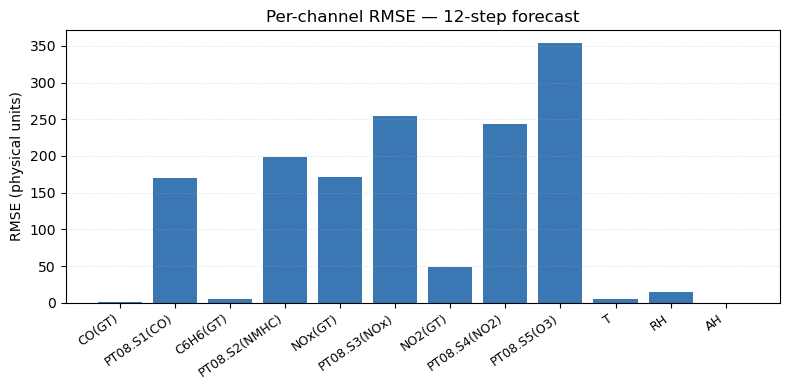

In [14]:
x = np.arange(NUM_FEATURES)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

ax.bar(x, ltae_rmse.numpy(), color='#185FA5', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('RMSE (physical units)')
ax.set_title(f'Per-channel RMSE — {H}-step forecast')
ax.grid(True, axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

### 9.3 Residual distributions

Residual histograms show whether errors are symmetric and centred around zero. A systematic bias (off-centre peak) would indicate that the model consistently over- or under-predicts a channel. We plot one panel per channel.

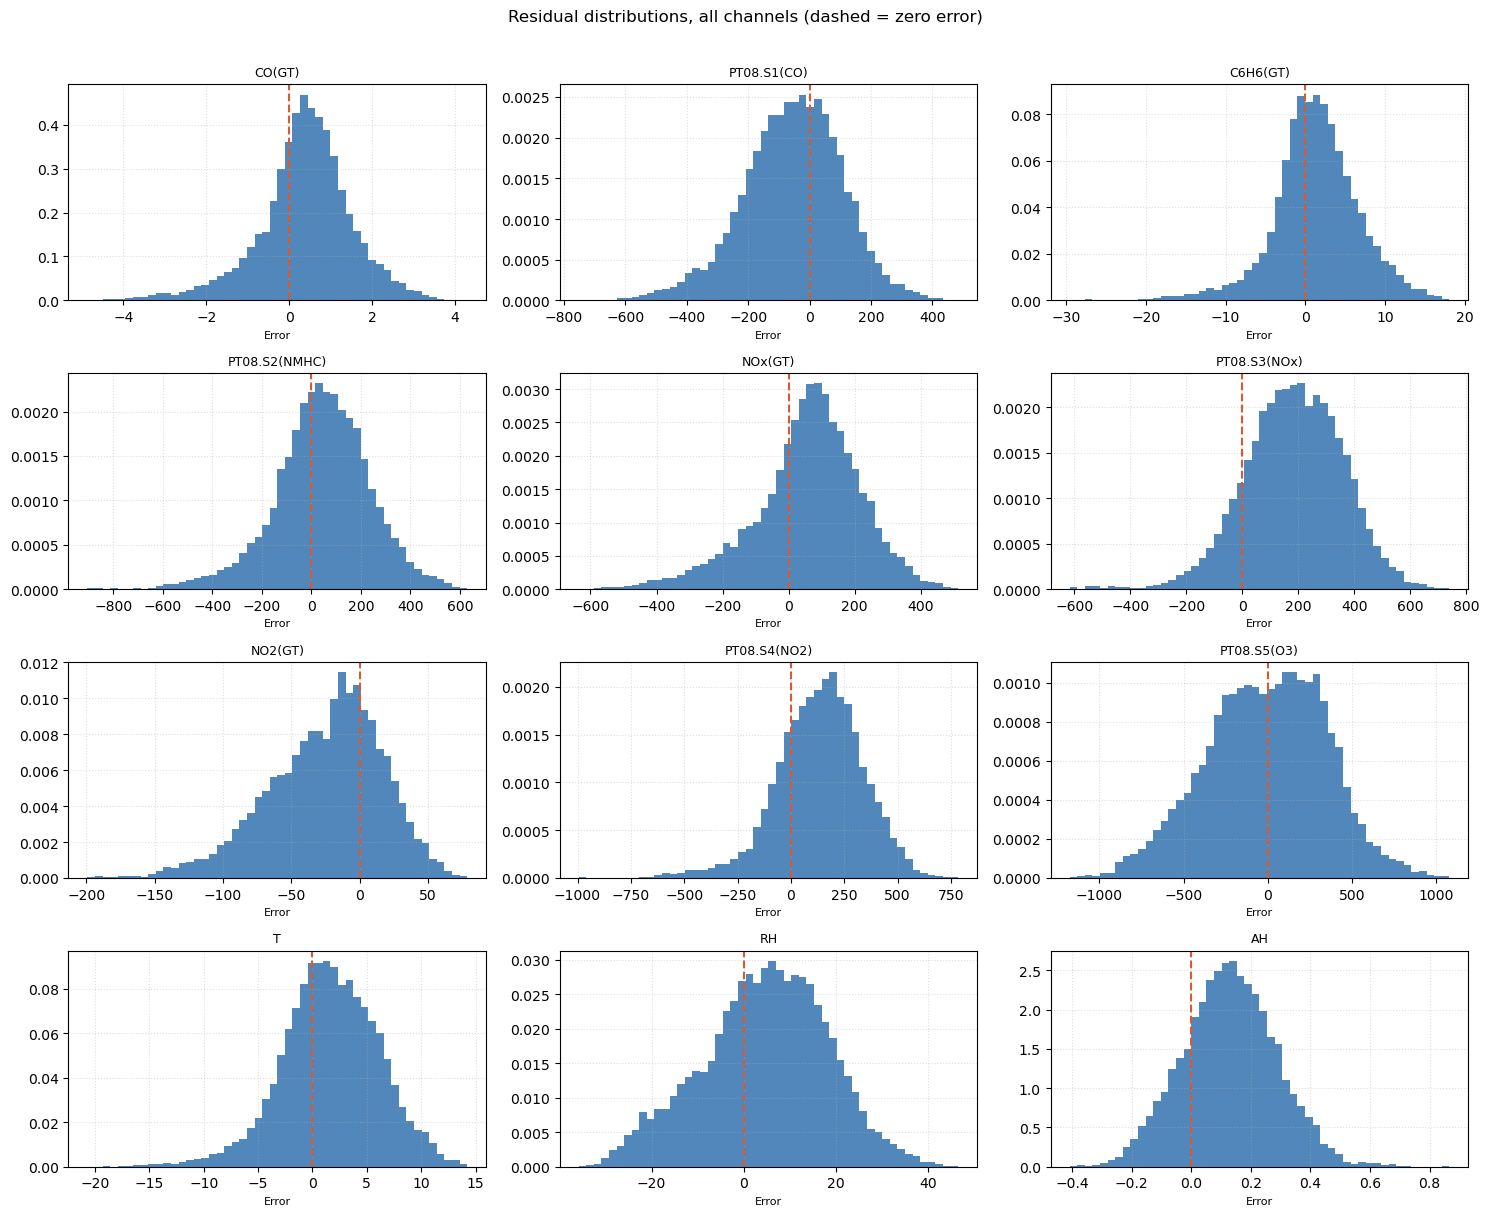

In [15]:
n_cols = 3
n_rows = int(np.ceil(NUM_FEATURES / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes_flat = axes.flatten()

for idx, name in enumerate(FEATURE_NAMES):
    residuals = (all_preds_2d[:, idx] - all_targets_2d[:, idx]).detach().numpy()
    axes_flat[idx].hist(residuals, bins=50, color='#185FA5', alpha=0.75, density=True)
    axes_flat[idx].axvline(0, color='#D85A30', linestyle='--', linewidth=1.5)
    axes_flat[idx].set_title(name, fontsize=9)
    axes_flat[idx].set_xlabel('Error', fontsize=8)
    axes_flat[idx].grid(True, linestyle=':', alpha=0.4)

for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Residual distributions, all channels (dashed = zero error)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Summary

In this tutorial we demonstrated a complete time-series regression workflow with TerraТorch's new components:

1. **`AirQuality` / `AirQualityDataModule`** loads and normalises the UCI air quality dataset, forming `(x_input, y_target)` pairs with a chronological train/val/test split that prevents data leakage.

2. **`LTAE`** encodes variable-length multivariate sequences into a fixed embedding via learned temporal attention, providing interpretable per-timestep weights and avoiding the limitations of RNNs.

3. **`TemporalRegressionTask`** a drop-in Lightning module that trains the encoder end-to-end with MSE loss and reports RMSE / MAE in physical units via de-normalisation.

From here, we can experiment with different context and horizon lengths (`NUM_PAST_STEPS`, `NUM_FUTURE_STEPS`), encoder capacity (`D_MODEL`, `N_HEAD`, `N_NEURONS`).